# 04 — CNN Baseline

Deep-learning baseline for the GTZAN music genre classification project.

**Run:** Runtime → Change runtime type → T4 GPU, then Runtime → Run all.


In [1]:
!pip -q install librosa soundfile scikit-learn pandas matplotlib
import os, sys
from pathlib import Path

REPO = Path('/content/music-genre-classification')
if not REPO.exists():
    !git clone -b feature/deep-learning https://github.com/SaimaKapoor/music-genre-classification.git /content/music-genre-classification
sys.path.insert(0, str(REPO))
print('Repository:', REPO)


Cloning into '/content/music-genre-classification'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 46 (delta 11), reused 37 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 61.80 KiB | 6.87 MiB/s, done.
Resolving deltas: 100% (11/11), done.
Repository: /content/music-genre-classification


## 1. Download the raw GTZAN audio
The audio stays in the temporary Colab runtime and is not uploaded to GitHub.


In [2]:
RAW_URL = 'https://ibm.ent.box.com/index.php?rm=box_download_shared_file&shared_name=gvkgmb4n0h6rbeccdwtwa0ujjjfmouof&file_id=f_961929491012'
ARCHIVE = '/content/genres.tar.gz'
if not os.path.exists(ARCHIVE):
    !wget -O /content/genres.tar.gz "$RAW_URL"
!mkdir -p /content/gtzan
!tar -xzf /content/genres.tar.gz -C /content/gtzan
!find /content/gtzan -maxdepth 2 -type d | head -20


--2026-10-08 08:36:28--  https://ibm.ent.box.com/index.php?rm=box_download_shared_file&shared_name=gvkgmb4n0h6rbeccdwtwa0ujjjfmouof&file_id=f_961929491012
Resolving ibm.ent.box.com (ibm.ent.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to ibm.ent.box.com (ibm.ent.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://public.boxcloud.com/d/1/b1!XRPaeBUU3MDiqyDvoEftg8IGVDsV-CP-WcZT4BRgZP7BQDkV88x7jwv0EUE1AHj00PqtzFedvoIcGpaDMeu6811lDsj290DQavkblu0IgC_wailLYtvjUtvnuCHK9BDJpDYdquC1a2i8Kb0EN-geVK-cYnR4IIbR0NC7nmVwFYY_6iOPhkl7SpXRhfLWQb0x9iuCD5qmkGxOyO2jgpcrMKtoa4s-dd5J4qOsTDAf-CuXiFQuohWOfRFJEy1eXTAsgpaANfFmfIpvdeS03HVHxz6E6gKOmYqrXQhop3ABpONqndQ_TtrV5hbDqnmnjSg07tFvlSavZR1mDVdVKP_mnDMghxfbtqQI7CVuw8JIl2ZP3ajOIZCyMq8UHioS1prvkuzBRQ4El5fTN296udIivBQaTXmTdD3ms316LR8mtRDH4Cf8XPaIZ1vypxAbq3potmM9kk8n6c1jeJvNYkWdXttNY3X0EG31dYEXc0O84fiSWMoJeuiF5aA2mdefUi1c44TYpQXDl0rZRbCYIg-0nDLWdUnHHCOMRfR0w5QAjH4jMtPyrKN--Jk4bd0hxd-UeRfnoMEW6

## 2. Upload the shared `split_manifest.csv`
Choose the CSV you generated earlier.


In [3]:
from google.colab import files
uploaded = files.upload()
assert 'split_manifest.csv' in uploaded, 'Please select split_manifest.csv'
MANIFEST = '/content/split_manifest.csv'


Saving split_manifest.csv to split_manifest.csv


In [4]:
import pandas as pd
manifest = pd.read_csv(MANIFEST)
print('Total songs:', len(manifest))
print('\nSplit counts:')
print(manifest['split'].value_counts())
print('\nGenre × split:')
print(pd.crosstab(manifest['genre'], manifest['split']))
assert len(manifest) == 1000
assert manifest['relative_path'].is_unique
assert set(manifest['split']) == {'train', 'validation', 'test'}


Total songs: 1000

Split counts:
split
train         700
test          150
validation    150
Name: count, dtype: int64

Genre × split:
split      test  train  validation
genre                             
blues        15     70          15
classical    15     70          15
country      15     70          15
disco        15     70          15
hiphop       15     70          15
jazz         15     70          15
metal        15     70          15
pop          15     70          15
reggae       15     70          15
rock         15     70          15


## 3. Create PyTorch datasets and loaders


In [5]:
import torch
from torch.utils.data import DataLoader
from src.deep_learning.dataset import GTZANMelDataset
from src.deep_learning.cnn import BaselineCNN
from src.deep_learning.train import fit
from src.deep_learning.evaluate import predict, classification_metrics

train_manifest = manifest[manifest['split'] == 'train'].copy()
val_manifest = manifest[manifest['split'] == 'validation'].copy()
test_manifest = manifest[manifest['split'] == 'test'].copy()

train_ds = GTZANMelDataset(train_manifest, '/content/gtzan', random_windows=True)
val_ds = GTZANMelDataset(val_manifest, '/content/gtzan', random_windows=False)
test_ds = GTZANMelDataset(test_manifest, '/content/gtzan', random_windows=False)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print('Train songs:', len(train_ds))
print('Validation songs:', len(val_ds))
print('Test songs:', len(test_ds))


Train songs: 700
Validation songs: 150
Test songs: 150


## 4. Inspect one log-mel spectrogram


Input tensor shape: (1, 64, 173)
Genre index: 0


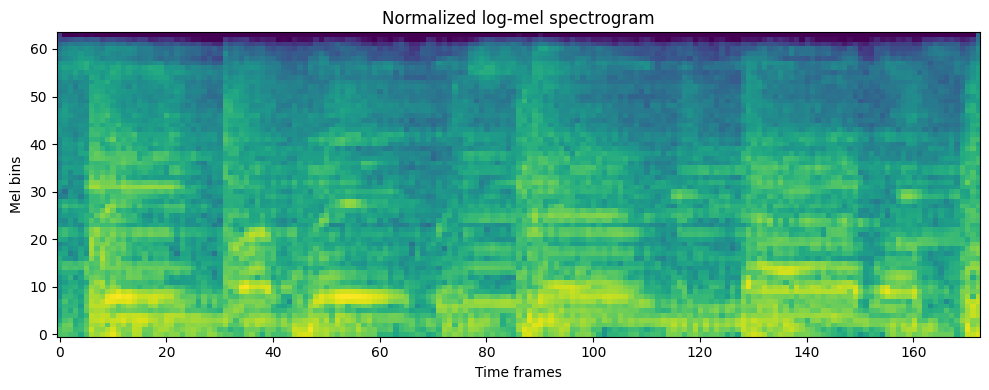

In [6]:
import matplotlib.pyplot as plt

x, y = train_ds[0]
print('Input tensor shape:', tuple(x.shape))
print('Genre index:', int(y))

plt.figure(figsize=(10, 4))
plt.imshow(x.squeeze(0).numpy(), aspect='auto', origin='lower')
plt.title('Normalized log-mel spectrogram')
plt.xlabel('Time frames')
plt.ylabel('Mel bins')
plt.tight_layout()
plt.show()


## 5. Train the baseline CNN

Baseline settings: 3 convolution blocks, max pooling, ReLU, dropout=0.30, Adam, learning rate=1e-3, batch size=32, 20 epochs.


In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)
if device == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

model = BaselineCNN(num_classes=10, dropout=0.30)
history = fit(
    model,
    train_loader,
    val_loader,
    epochs=20,
    learning_rate=1e-3,
    device=device,
    checkpoint_path='/content/best_cnn_baseline.pt'
)


Epoch 03/20 | train loss 2.0369 | train acc 0.2571 | val loss 1.8378 | val acc 0.2667
Epoch 04/20 | train loss 1.9338 | train acc 0.2886 | val loss 1.8250 | val acc 0.3467
Epoch 05/20 | train loss 1.8973 | train acc 0.3100 | val loss 1.7788 | val acc 0.3067
Epoch 06/20 | train loss 1.8137 | train acc 0.3314 | val loss 1.6311 | val acc 0.3867
Epoch 07/20 | train loss 1.7469 | train acc 0.3614 | val loss 1.5944 | val acc 0.3933
Epoch 08/20 | train loss 1.6759 | train acc 0.3957 | val loss 1.5247 | val acc 0.4267
Epoch 09/20 | train loss 1.6274 | train acc 0.4071 | val loss 1.4564 | val acc 0.4400
Epoch 10/20 | train loss 1.5892 | train acc 0.4143 | val loss 1.3736 | val acc 0.5067
Epoch 11/20 | train loss 1.5913 | train acc 0.4100 | val loss 1.4051 | val acc 0.4600
Epoch 12/20 | train loss 1.5690 | train acc 0.4400 | val loss 1.5778 | val acc 0.4267
Epoch 13/20 | train loss 1.5690 | train acc 0.4371 | val loss 1.3316 | val acc 0.4933
Epoch 14/20 | train loss 1.4900 | train acc 0.4586 | v

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/20 | train loss 2.3008 | train acc 0.1157 | val loss 2.2595 | val acc 0.1667
Epoch 02/20 | train loss 2.1908 | train acc 0.1929 | val loss 2.0105 | val acc 0.2267
Epoch 03/20 | train loss 2.0645 | train acc 0.2486 | val loss 1.8854 | val acc 0.3000
Epoch 04/20 | train loss 1.9460 | train acc 0.2886 | val loss 1.7713 | val acc 0.3400


## 6. Evaluate the held-out test songs


In [8]:
y_true, y_pred = predict(model, test_loader, device=device)
metrics = classification_metrics(y_true, y_pred)
print(f"Test accuracy: {metrics['accuracy']:.4f}")
print(f"Test macro-F1: {metrics['macro_f1']:.4f}")
print('\nClassification report:')
print(metrics['report'])


Test accuracy: 0.5533
Test macro-F1: 0.5451

Classification report:
              precision    recall  f1-score   support

           0     0.4231    0.7333    0.5366        15
           1     0.7647    0.8667    0.8125        15
           2     0.3000    0.2000    0.2400        15
           3     0.7000    0.4667    0.5600        15
           4     0.7143    0.3333    0.4545        15
           5     0.5625    0.6000    0.5806        15
           6     0.6875    0.7333    0.7097        15
           7     0.8000    0.8000    0.8000        15
           8     0.3684    0.4667    0.4118        15
           9     0.3571    0.3333    0.3448        15

    accuracy                         0.5533       150
   macro avg     0.5678    0.5533    0.5451       150
weighted avg     0.5678    0.5533    0.5451       150



In [9]:
history_df = pd.DataFrame(history)
history_df.to_csv('/content/cnn_baseline_history.csv', index=False)
print('Saved /content/cnn_baseline_history.csv')


Saved /content/cnn_baseline_history.csv
